##### Inital settings and import dependecies

In [ ]:
import sys
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np

from explainability_utils import *

# Add the 'training' directory to sys.path
sys.path.append(os.path.abspath("../training"))
from training_utils import CNN2D, SpectraDataset_s

In [10]:
# Path to the data
data_path_64 = "../preprocessed_dset/sp_64"
data_path_32 = "../preprocessed_dset/sp_32"
meta_path = "../preprocessed_dset/features_and_metadata.csv"

output_path = "shap_tensors"
os.makedirs(output_path, exist_ok=True)
MAX_EVALS = 5000

data_path_64_s = os.path.join(data_path_64, "explainer_s_wave")
data_path_32_s = os.path.join(data_path_32, "explainer_s_wave")

f_t_range_64_path = os.path.join(data_path_64, "f_t_range.npy")
f_t_range_32_path = os.path.join(data_path_32, "f_t_range.npy")
tf64, tf32 = np.load(f_t_range_64_path), np.load(f_t_range_32_path)

ft = [tf64[:2], tf64[2:], tf32[:2], tf32[2:]]


# Path to the best model found in the training notebooks
best_model_s_64 = "../training/models/s_wave_model_checkpoints/model_checkpoints_64/best_model_fold.ckpt"
best_model_s_32 = "../training/models/s_wave_model_checkpoints/model_checkpoints_32/best_model_fold_s.ckpt"

dim_s64 = (33, 61)
dim_s32 = (17, 282)

# Setting for the datasets
mean_64, std_64 = spectra_stats(os.path.join(data_path_64, "train"))
mean_32, std_32 = spectra_stats(os.path.join(data_path_32, "train"))

transform_64 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_64, std=std_64)
])

transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_32, std=std_32)
])

MST = dict() # MEAN SHAP TENSOR dict

(../preprocessed_dset/sp_64\train) Mean: [0.65270317 0.63808999 0.62043287], Std: [0.12674917 0.12843871 0.12783305] (calculated and saved)
(../preprocessed_dset/sp_32\train) Mean: [0.66824939 0.65407392 0.6375849 ], Std: [0.1154479  0.11722113 0.11654203] (calculated and saved)


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Explainability on S-Wave fixed Spectrograms

### Spectra64 Settings

In [12]:
model = CNN2D.load_from_checkpoint(best_model_s_64, input_dim=dim_s64, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [13]:
dset_pre = SpectraDataset_s(os.path.join(data_path_64_s, "foreshock"),meta_path=meta_path, transform=transform_64, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

In [ ]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_s64, device, max_evals = MAX_EVALS, masker_settings = "inpaint_telea", save_path = os.path.join(output_path, f"foreshock_s64_{MAX_EVALS}.npy"))

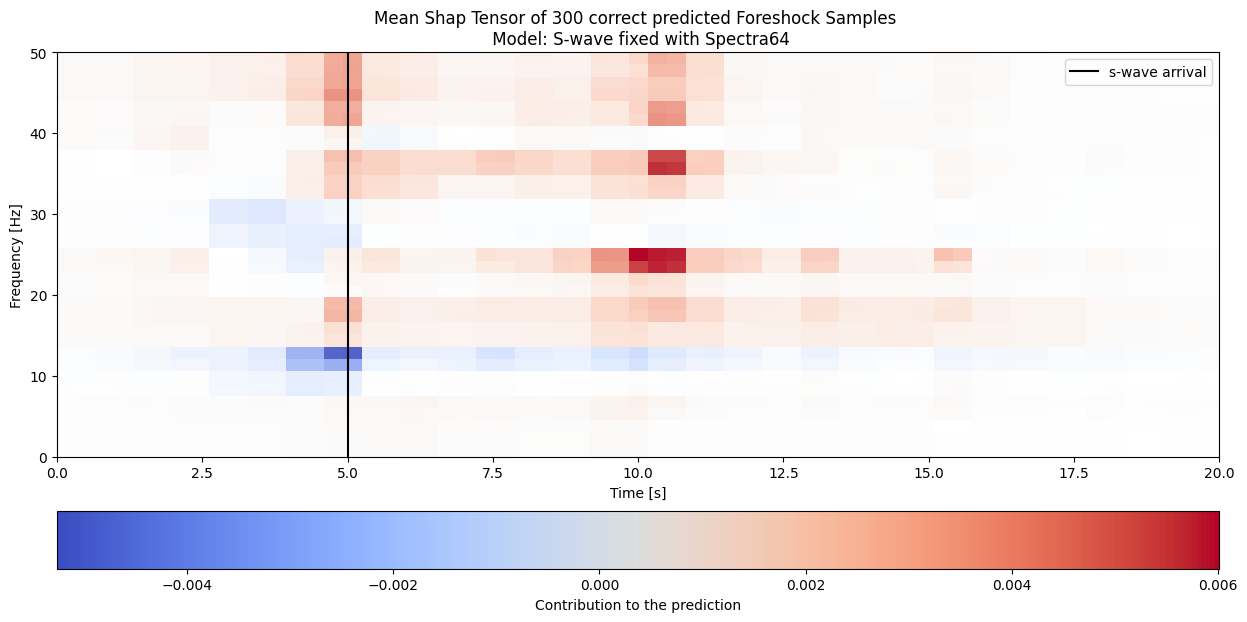

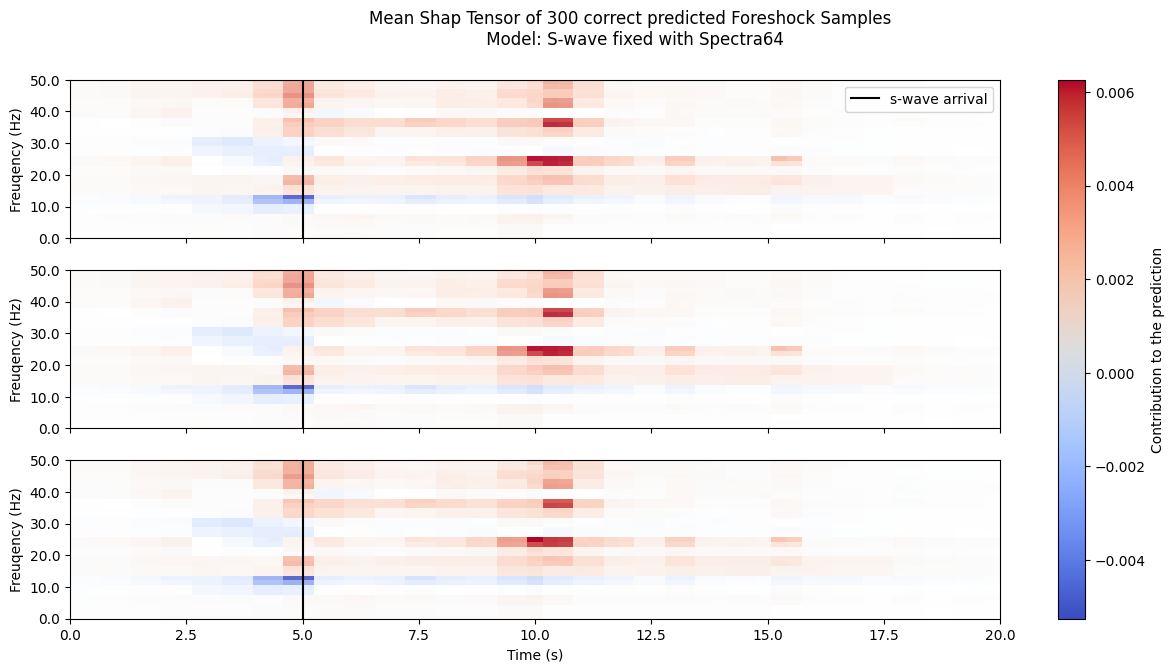

In [15]:
MST["f_s64"] = np.load(os.path.join(output_path, f"foreshock_s64_{MAX_EVALS}.npy"))
plot_shap(MST["f_s64"], onechannel=True, background=None, ft = ft, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra64")
plot_shap(MST["f_s64"], onechannel=False, background=None, ft = ft, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra64")

#### Aftershocks

In [16]:
dset_post = SpectraDataset_s(os.path.join(data_path_64_s, "aftershock"), meta_path = meta_path, transform=transform_64, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [ ]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_s64, device, max_evals = MAX_EVALS, masker_settings = "inpaint_telea", save_path = os.path.join(output_path, f"aftershock_s64_{MAX_EVALS}.npy"))

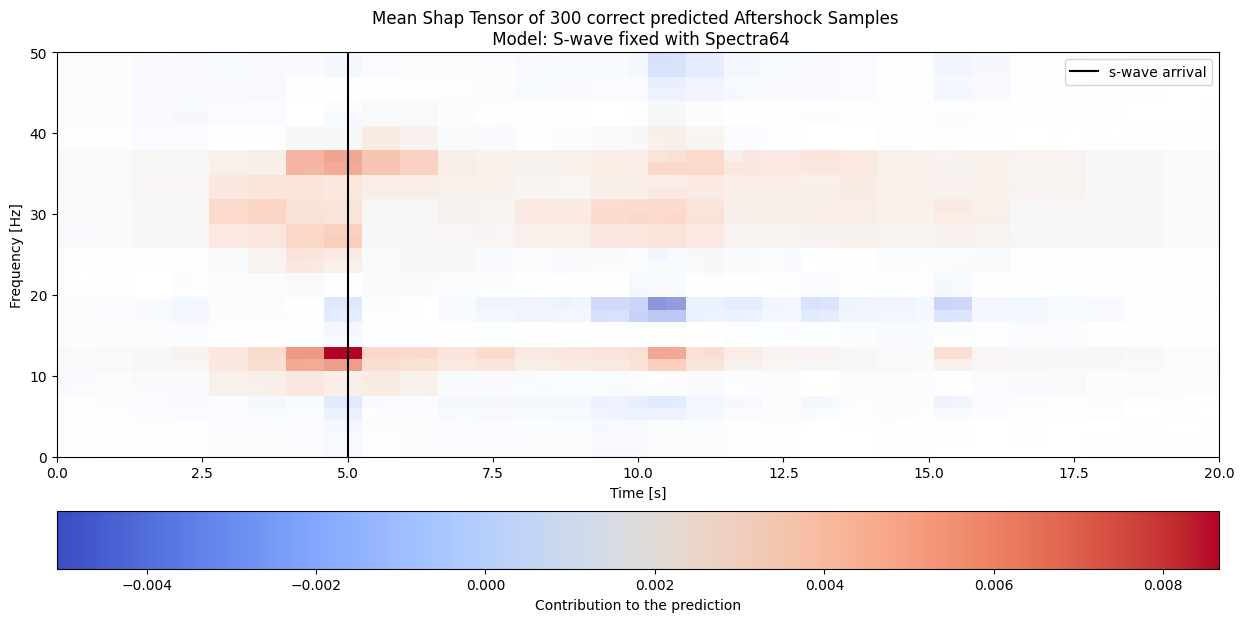

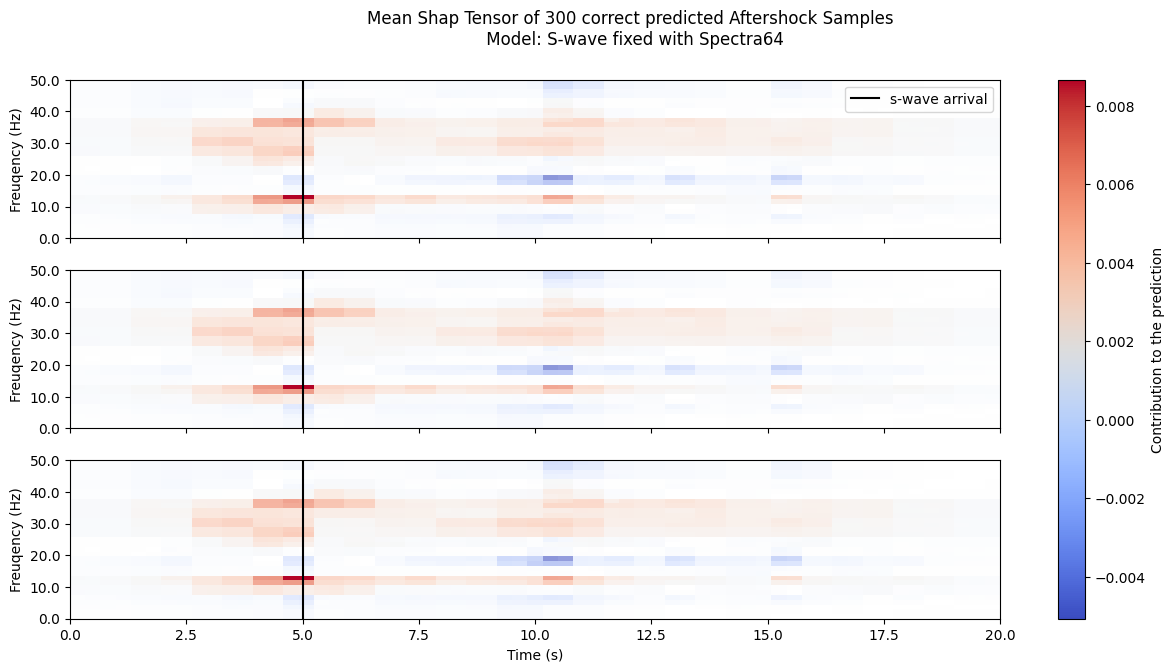

In [18]:
MST["a_s64"] = np.load(os.path.join(output_path, f"aftershock_s64_{MAX_EVALS}.npy"))
plot_shap(MST["a_s64"], onechannel=True, background=None, ft = ft, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra64")
plot_shap(MST["a_s64"], onechannel=False, background=None, ft = ft, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra64")

### Spectra32 Settings

In [19]:
model = CNN2D.load_from_checkpoint(best_model_s_32, input_dim=dim_s32, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [20]:
dset_pre = SpectraDataset_s(os.path.join(data_path_32_s, "foreshock"), meta_path = meta_path, transform=transform_32, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

In [ ]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_s32, device, max_evals = MAX_EVALS, masker_settings = "inpaint_telea", save_path = os.path.join(output_path, f"foreshock_s32_{MAX_EVALS}.npy"))

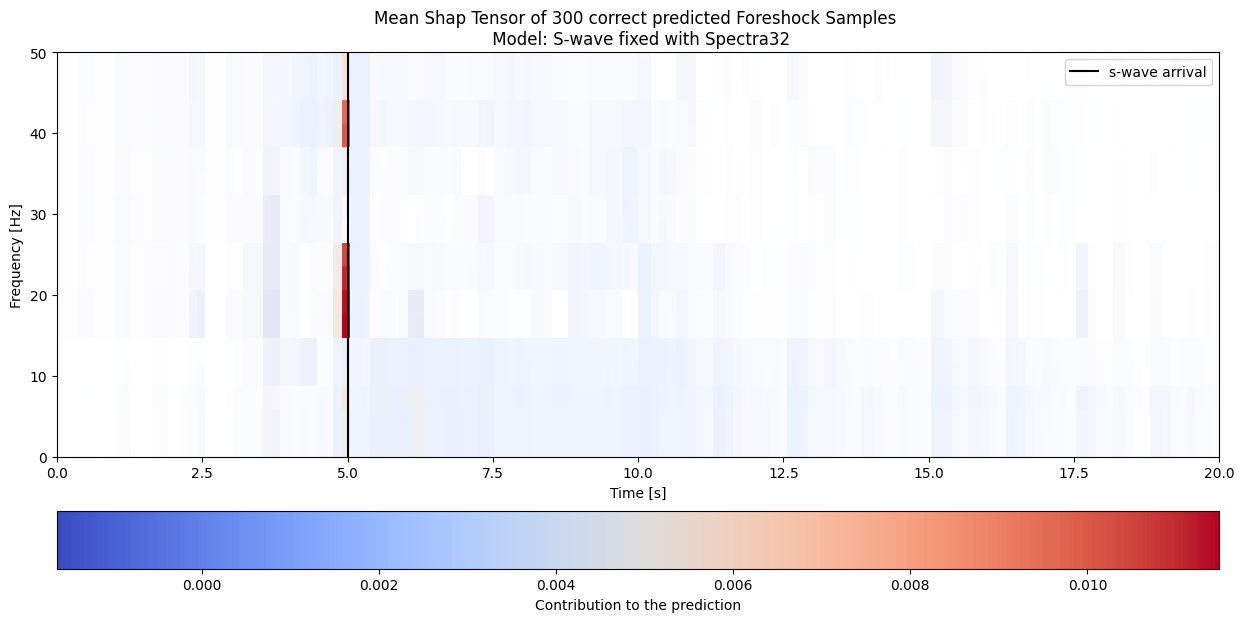

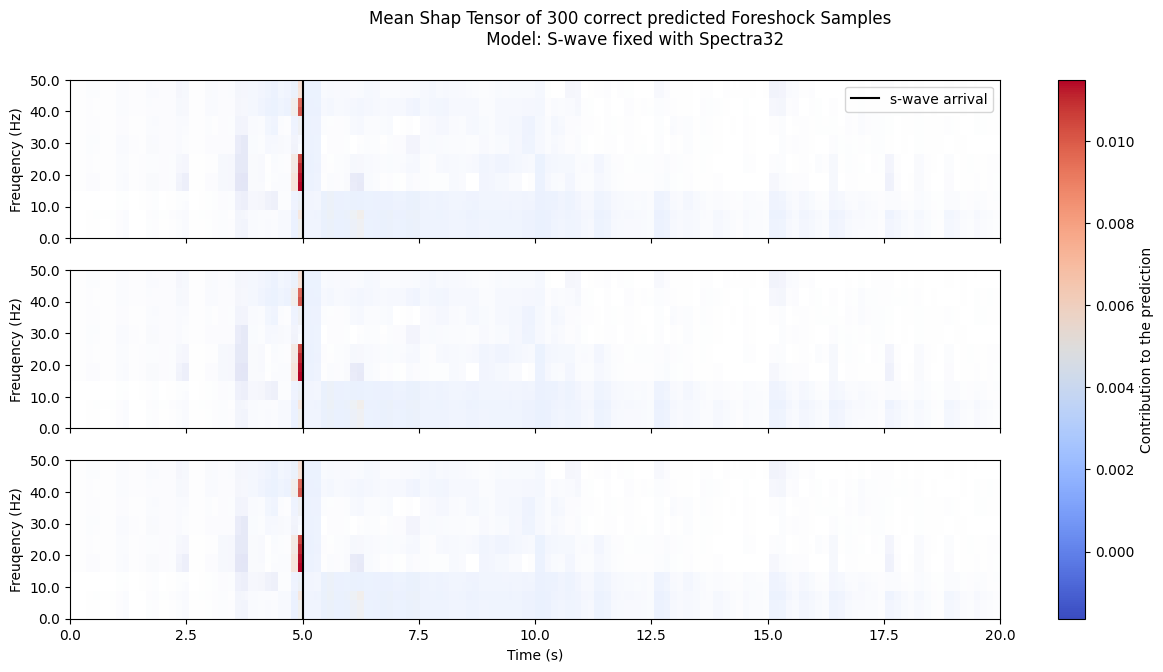

In [22]:
MST["f_s32"] = np.load(os.path.join(output_path, f"foreshock_s32_{MAX_EVALS}.npy"))
plot_shap(MST["f_s32"], onechannel=True, background=None, ft = ft, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra32")
plot_shap(MST["f_s32"], onechannel=False, background=None, ft = ft, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra32")

#### Aftershocks

In [23]:
dset_post = SpectraDataset_s(os.path.join(data_path_32_s, "aftershock"), meta_path=meta_path, transform=transform_32, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [ ]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_s32, device, max_evals = MAX_EVALS, masker_settings = "inpaint_telea", save_path = os.path.join(output_path, f"aftershock_s32_{MAX_EVALS}.npy"))

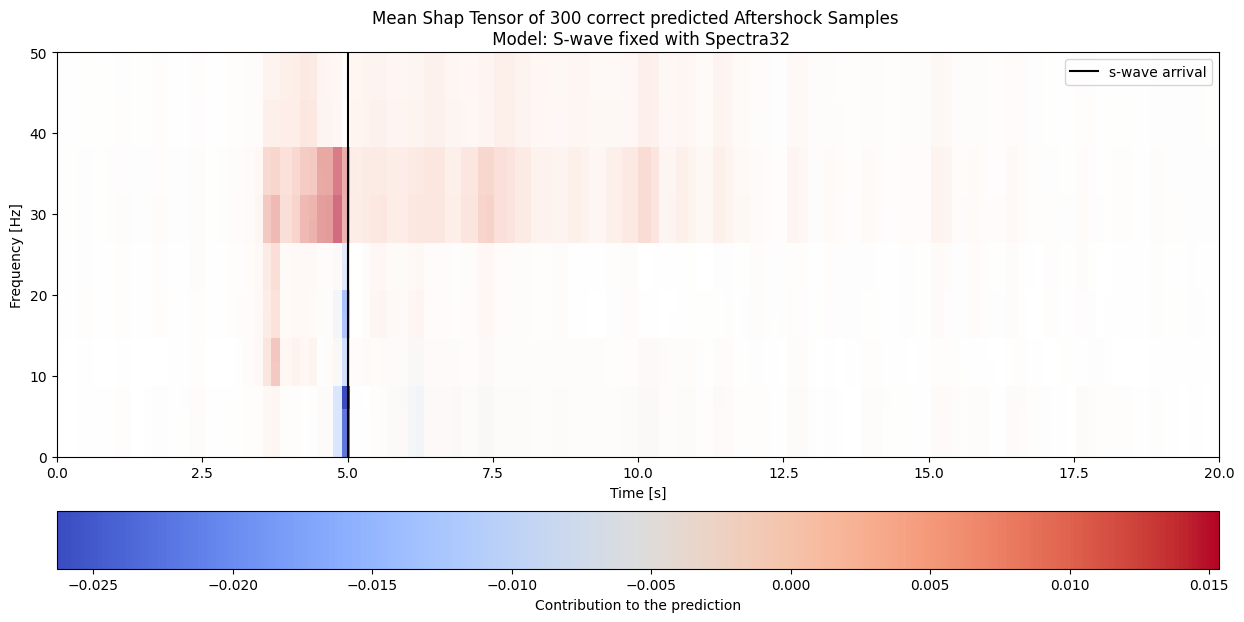

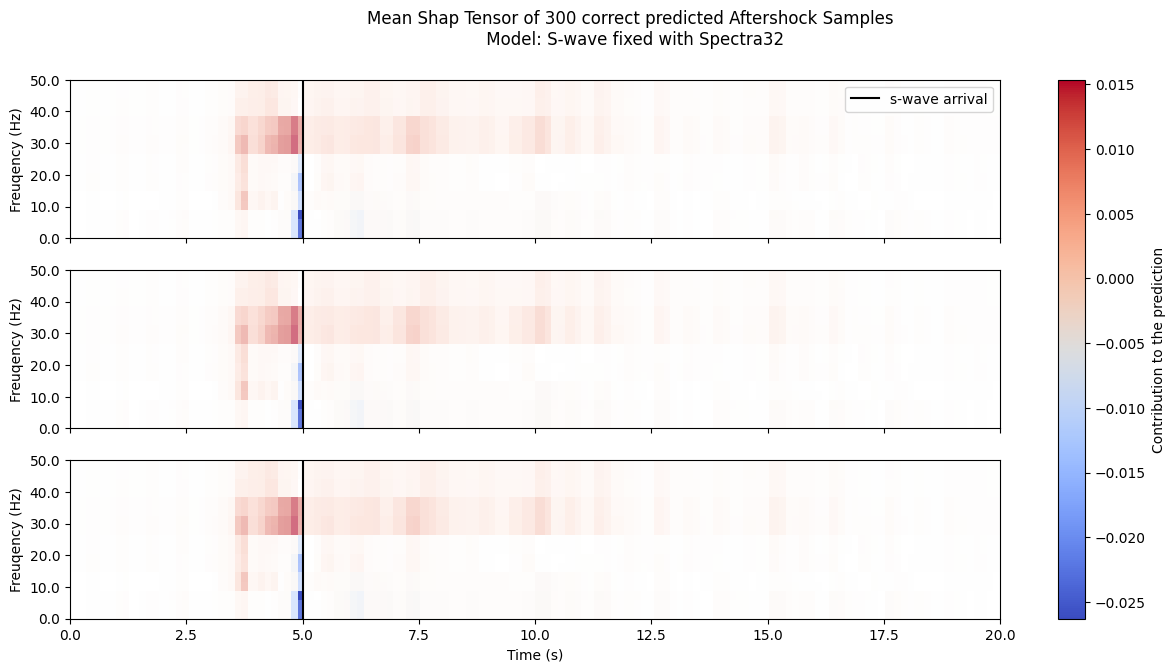

In [25]:
MST["a_s32"] = np.load(os.path.join(output_path, f"aftershock_s32_{MAX_EVALS}.npy"))
plot_shap(MST["a_s32"], onechannel=True, background=None, ft = ft, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra32")
plot_shap(MST["a_s32"], onechannel=False, background=None, ft = ft, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra32")